# Priors


Option 1: Prior from biological knowledge

https://www.sciencedirect.com/science/article/pii/S147330991630319X?casa_token=ea-3lDo8ia4AAAAA:JwutAIbXtgoRr0pti9mcged5URn9UE0jqwDOhqTd_kBB3ucycN7sYahpX0wKCGvYFHK61nduTCo


Option 2: Priors for net transmission rate and R, reparametrize SIR


Option 3: Gamma priors for $\beta$ (birth rate) and $\gamma$ (death/recovery rate)



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, gamma
import elfi
import scipy.stats

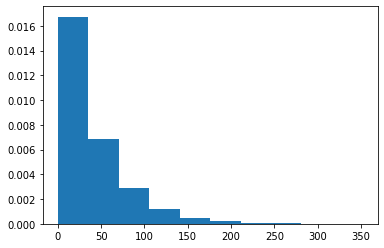

In [2]:
# Option 1:

# Estimate the KM-curve by an exponential distribution 


surv = np.random.exponential(scale=1.0)
#print(surv)
x = expon.rvs(scale=40, size=10000)

plt.hist(x, density=True)
plt.show()

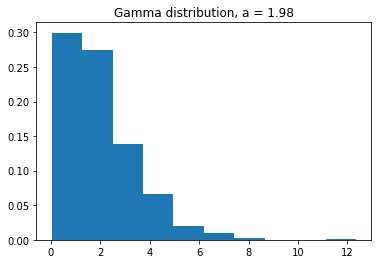

In [3]:
a = 1.98
r = gamma.rvs(a, size = 1000)

plt.hist(r, density = True)
plt.title(f'Gamma distribution, a = {a}')
plt.show()

## A simple model with priors for net transmission rate and R

$a$ is the birth rate, $b$ is the death rate. The net transmission rate is $t = a - b$ and $R = a/b$.

From these: 

$b = \frac{t}{R - 1}$ and $a = \frac{t}{1 - \frac{1}{R}}$

The priors:

$$p(t) = \Gamma()$$

$$p(R) = U(2,10)$$

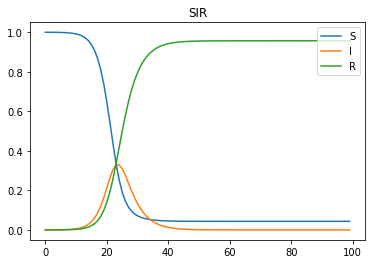

In [9]:
# SIR in terms of t and R
def dS(S, I, t, beta, N, is_prop = False):
    if is_prop:
        #print(f'S[t]: {S[:,t].shape}')
        return -beta*S[:,t]*I[:,t]#.reshape(-1,1)
    return -beta*S[:,t]*I[:,t]/N[t]

def dI(I, S, t,beta, gamma, N, is_prop = False):
    
    if is_prop:
        return beta*S[:,t]*I[:,t] - gamma*I[:,t]
    return beta*S[:,t]*I[:,t]/N[t] - gamma*I[:,t]

def dR(I, t, gamma):
    
    return gamma*I[:,t]

def SIR_reparam(net_transmission, R, nt, N, batch_size=1, random_state = None):

    thetaS = np.zeros((batch_size, nt))
    thetaI = np.zeros((batch_size, nt))
    thetaR = np.zeros((batch_size, nt))
    
    thetaS[:,0] = N-1
    thetaI[:,0] = 1
    thetaR[:,0] = 0
    
    thetaS[:,0] = thetaS[:,0]/N # recommendation: make S0 the same as N - I0
    thetaI[:,0] = thetaI[:,0]/N
    thetaR[:,0] = thetaR[:,0]/N
    
    N = np.array([N]*nt)
    
    a = net_transmission/(1 - 1/R)
    b = net_transmission/(R - 1)

    
    for t in range(0, nt-1):

        thetaS[:,t + 1] = thetaS[:,t] + dS(thetaS, thetaI, t, a, N, is_prop = True)
        thetaI[:,t + 1] = thetaI[:,t] + dI(thetaI, thetaS, t, a, b, N, is_prop = True)
        thetaR[:,t + 1] = thetaR[:,t] + dR(thetaI, t, b)
        
    return thetaS, thetaI, thetaR
  
SIR_sim_data = SIR_reparam(0.5, 3, 100, 10000)

plot_SIR(SIR_sim_data)

In [11]:
# elfi summaries

def I_var(y):
    return np.var(y[1][:,], axis=1)

def I_max(y):
    
    return np.max(y[1][:,], axis = 1)

def I_mean(y):
    #print(y)
    #print(y[1])
    return np.mean(y[1][:,], axis=1)

-0.004420994090650464


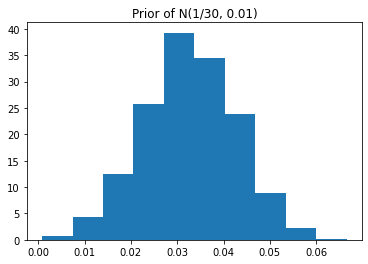

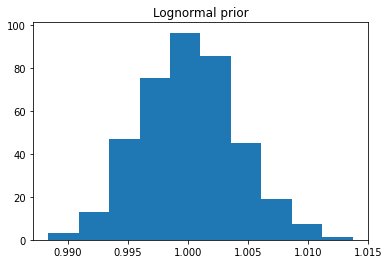

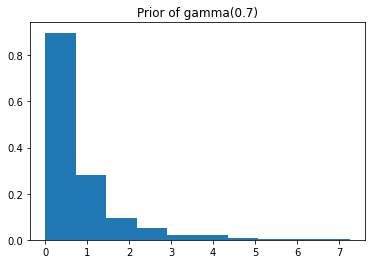

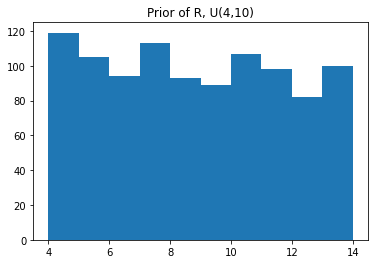

In [56]:
# plot the priors:
print(np.min(scipy.stats.norm.rvs(0.033, 0.01, size = 1000)))
plt.hist(scipy.stats.norm.rvs(0.033, 0.01, size = 1000), density = True) # can be less than 0... Maybe 
plt.title("Prior of N(1/30, 0.01)")
plt.show()

plt.hist(scipy.stats.gamma.rvs(0.7, size = 1000), density = True)
plt.title("Prior of gamma(0.7)")
plt.show()

plt.hist(scipy.stats.uniform.rvs(4,10, size = 1000))
plt.title("Prior of R, U(4,10)")
plt.show()

In [40]:
# elfi model
elfi.new_model()

bs = 20

# simulated data:
n_weeks = 200
pop_size = 100000
SIR_obs = SIR_reparam(0.5, 6, nt = n_weeks, N = pop_size, batch_size = 1)   
print(SIR_obs[1].shape)


net_transmission = elfi.Prior(scipy.stats.gamma, 1.5)
#gamma = elfi.Prior(scipy.stats.uniform, 0, 1)
#gamma = elfi.Constant(1/30)
R = elfi.Prior(scipy.stats.uniform, 2, 10)

nt = elfi.Constant(n_weeks)
N = elfi.Constant(pop_size)

SIR = elfi.Simulator(SIR_reparam, net_transmission, R, nt, N, observed = SIR_obs)

S1 = elfi.Summary(I_max, SIR)
S2 = elfi.Summary(I_var, SIR)
#S3 = elfi.Summary(I_max,SIR)
#S4 = elfi.Summary(S_min_bsi, BSI) we are comparing BSI, can't use S curve to compare.

d = elfi.Distance('euclidean', S1, S2)

elfi.draw(d)

NameError: name 'SIR_reparam' is not defined

(1, 200)


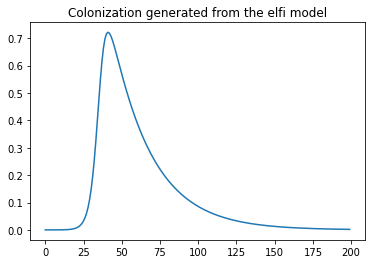

In [133]:
print(SIR.generate(1)[1].shape)

SIR.generate(1)[1]

plt.plot(SIR.generate(1)[1][0])
plt.title("Colonization generated from the elfi model")
plt.show()

# problem: can lead to negative values in the colonisation.

In [136]:
pool = elfi.OutputPool(["net_transmission", "R", "S1", "S2"])
smc = elfi.AdaptiveThresholdSMC(d, batch_size=bs, seed=2, q_threshold=0.995)
smc_samples = smc.sample(4000, max_iter=10)

ABC-SMC Round 1 / 10


 <ipython-input-104-a392705a8762>:5: RuntimeWarning:overflow encountered in multiply
 <ipython-input-104-a392705a8762>:11: RuntimeWarning:overflow encountered in multiply
 <ipython-input-104-a392705a8762>:11: RuntimeWarning:invalid value encountered in subtract


 <ipython-input-104-a392705a8762>:16: RuntimeWarning:overflow encountered in multiply


Progress [==================================================] 100.0% Complete
ABC-SMC Round 2 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 3 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 4 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 5 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 6 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 7 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 8 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 9 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 10 / 10
Progress [==================================================] 100.0% Complete


Method: AdaptiveThresholdSMC
Number of samples: 4000
Number of simulations: 348920
Threshold: 0.0155
Parameter                Mean               2.5%              97.5%
R:                      5.436              3.701              6.485
net_transm:              0.940              0.237              2.273




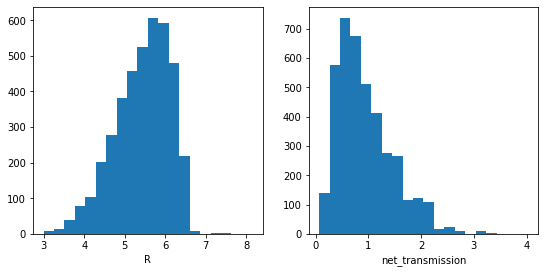

In [137]:
print(smc_samples)
smc_samples.plot_pairs()
plt.show()

# Gamma prior

Clancy et al:

$$\Gamma(m, \lambda),$$

where $m = 1$ and $\lambda$ is some small number $\epsilon$. These priors are set for both $\beta$ (a) and $\gamma$ (b).



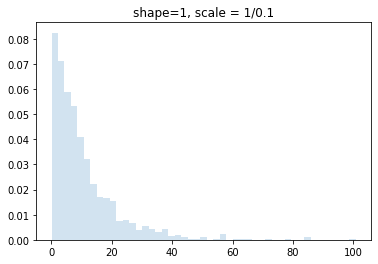

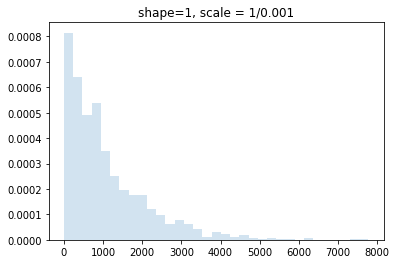

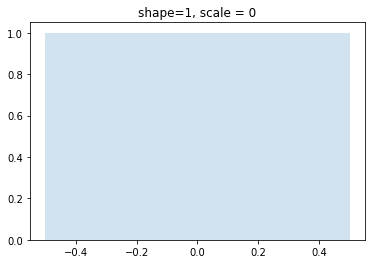

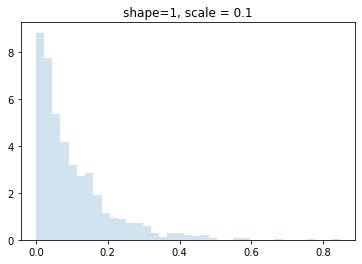

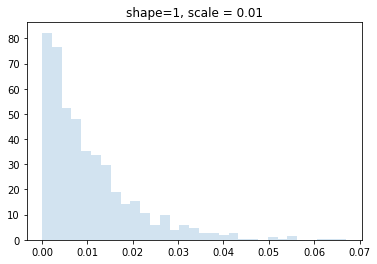

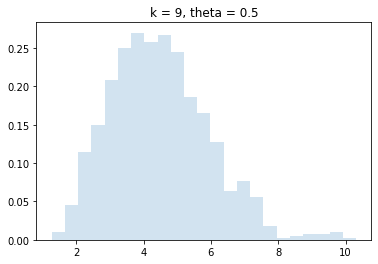

In [132]:
m = 1
l = 0.1

r = scipy.stats.gamma.rvs(m,0,1/l, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 1/0.1")
plt.show()


r = scipy.stats.gamma.rvs(m,0,1/0.001, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 1/0.001")
plt.show()

r = scipy.stats.gamma.rvs(a=m, scale = 0, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 0")
plt.show()

r = scipy.stats.gamma.rvs(m,0,0.1, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 0.1")
plt.show()

r = scipy.stats.gamma.rvs(m,0,0.01, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 0.01")
plt.show()

r = scipy.stats.gamma.rvs(a=9, scale = 0.5, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("k = 9, theta = 0.5")
plt.show()

# based on these, scale should be 1/lambda, where lambda = beta = the param metioned in Clancy et al paper. Otherwise, the prior is too restricted.

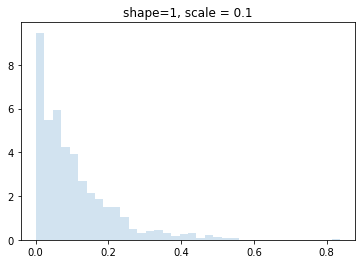

In [158]:
# prior of choice:

r = scipy.stats.gamma.rvs(m,0,0.1, size=1000)
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.title("shape=1, scale = 0.1")
plt.show()

In [128]:
from SIR_functions import *

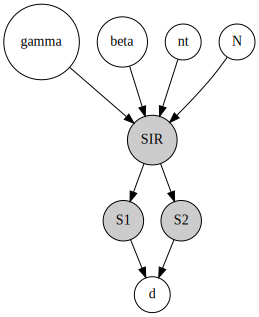

In [155]:
# elfi model
elfi.new_model()

bs = 20

# simulated data:
n_weeks = 200
pop_size = 100000
SIR_obs = propSIR_simulator(0.7, 0.1, nt = n_weeks, N = pop_size, batch_size = 1)   
print(SIR_obs[1].shape)



gamma = elfi.Prior(scipy.stats.gamma, 1, 0, 0.1)
#gamma = elfi.Constant(1/30)
beta = elfi.Prior(scipy.stats.gamma, 1, 0, 0.1)

nt = elfi.Constant(n_weeks)
N = elfi.Constant(pop_size)

SIR = elfi.Simulator(propSIR_simulator, beta, gamma, nt, N, observed = SIR_obs)

S1 = elfi.Summary(I_max, SIR)
S2 = elfi.Summary(I_var, SIR)
#S3 = elfi.Summary(I_max,SIR)
#S4 = elfi.Summary(S_min_bsi, BSI) we are comparing BSI, can't use S curve to compare.

d = elfi.Distance('euclidean', S1, S2)

elfi.draw(d)

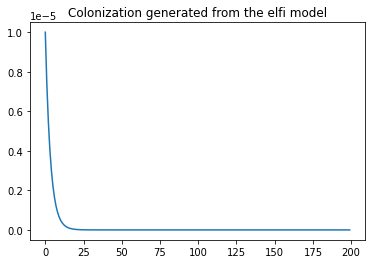

In [156]:
print(SIR.generate(1)[1].shape)

SIR.generate(1)[1]

plt.plot(SIR.generate(1)[1][0])
plt.title("Colonization generated from the elfi model")
plt.show()

In [157]:
smc = elfi.AdaptiveThresholdSMC(d, batch_size=bs, seed=2, q_threshold=0.995)
smc_samples = smc.sample(1000, max_iter=10)

KeyboardInterrupt: 

In [ ]:
print(smc_samples)

In [ ]:
smc_samples.plot_pairs()
#plt.xlim(0.87,0.879)
plt.show()

### Notes on the gamma prior: parametrisation

elfi.Prior(scipy.stats.gamma, 1, 0, 0.1)

- SIR.generate() produces nicely varying colonisation curves
- Might restrict the SMC quite a lot -> slow, because more values are rejected than accepted I guess

elfi.Prior(scipy.stats.gamma, 1, 0, 1/0.1)

- SIR.generate() might produce some weird oscillations, 1/0.1 is probably wrong.